# 10 — Portfolio Construction

**Chain position:** … → Companies → Validation → Forensics → Crowding → `Construction`

Eight names and no sizes is a watchlist. This notebook turns the ranking into a book: how
much of each, long and short, at what gross, and — the part most write-ups skip — whether
the resulting weights can actually be traded.

### The mandate

Long/short market-neutral. Longs come from notebook 08's forensically filtered screen;
shorts from 08's ranked short candidates. The legs are **beta-matched**, not merely
dollar-matched: a long book of high-beta names against an equal-rupee short book of
low-beta names is still a long position in the market wearing a neutral label.

### Gross exposure is where the macro chain finally pays

Everything from notebook 01 to 05 has so far been context. Here it becomes a number:
`portfolio.regime_gross()` reads notebook 02's risk label and notebook 01's macro nowcast
out of `dashboard.json` and sets gross exposure from `config.GROSS_BY_REGIME`. Risk-off
cuts the book. That is the entire point of having built the top-down chain.

### Trap #5 — the shortability trap

A market-neutral book with continuous weights is **unimplementable in India**. Cash-market
shorts cannot be carried overnight; they are intraday only. An overnight short must be a
stock future, which means:

- only F&O-eligible names — all 50 Nifty constituents qualify, but that stops being true
  the moment the universe widens;
- **whole lots**, so short weights quantise. One lot of a Nifty 50 name costs between
  ₹4.3 lakh and ₹11.0 lakh — **4.3% to 11.0% of a ₹1 crore book per single lot**;
- SEBI's F&O ban list makes names un-shortable on any given day, and margin is SPAN+ELM on
  the notional rather than on the net.

The long leg has no such problem: cash equity buys in single shares.

So sizing runs **after** lot sizes are known — which is why notebook 09 comes first —
and section 7 prints realised weights next to target weights so the tracking error lot
rounding introduces is a number in a table rather than an assumption.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard, portfolio as pf,
                 risk as rk, backtest as bt, indicators as ind, score, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

CAPITAL = config.DEFAULT_CAPITAL
N_LONG, N_SHORT = 6, 5

print(f"capital          : INR {CAPITAL:,.0f}")
print(f"target vol       : {config.TARGET_PORTFOLIO_VOL_PCT}%")
print(f"position cap     : {config.MAX_POSITION_WEIGHT:.0%}   sector cap {config.MAX_SECTOR_WEIGHT:.0%}")
print(f"short instrument : {config.SHORT_LEG_INSTRUMENT}")

mkt v2.0.0 | run 2026-09-11 12:48 | REFRESH=False | cache=G:\stock market analysis\.claude\worktrees\code-review-quotes-3844ce\data\cache
capital          : INR 10,000,000
target vol       : 12.0%
position cap     : 12%   sector cap 30%
short instrument : stock futures (overnight cash shorts are not permitted)


## 1. The two candidate lists

Longs from `outputs/nifty50_screen_filtered.csv` — notebook 06's screen with notebook 08's
do-not-own names removed. Shorts from notebook 08's ranked candidates in `dashboard.json`.

In [2]:
filt_path = config.OUTPUT_DIR / "nifty50_screen_filtered.csv"
if not filt_path.exists():
    raise FileNotFoundError(f"{filt_path} not found -- run notebook 08 first.")
filtered = pd.read_csv(filt_path, index_col=0)

data = dashboard.read()
short_block = data.get("08_earnings_quality", {}).get("short_candidates", {})
if not short_block:
    raise RuntimeError("no short candidates in dashboard.json -- run notebook 08 first.")

long_names = list(filtered.nsmallest(N_LONG, "rank_filtered").index)
short_names = [t for t in short_block][:N_SHORT]
overlap = set(long_names) & set(short_names)
if overlap:
    short_names = [t for t in short_names if t not in overlap]
    print(f"removed {overlap} from the short leg -- a name cannot be both sides")

print(f"LONG  ({len(long_names)}): " + ", ".join(t.replace('.NS', '') for t in long_names))
print(f"SHORT ({len(short_names)}): " + ", ".join(t.replace('.NS', '') for t in short_names))

sectors = {t: config.NIFTY_50.get(t, "?") for t in long_names + short_names}
display(pd.DataFrame({
    "side": ["long"] * len(long_names) + ["short"] * len(short_names),
    "sector": [sectors[t] for t in long_names + short_names],
    "composite": [filtered["composite"].get(t, np.nan) for t in long_names]
                 + [short_block[t]["composite"] for t in short_names],
    "quality": [filtered["quality_score"].get(t, np.nan) for t in long_names]
               + [short_block[t]["quality_score"] for t in short_names],
}, index=long_names + short_names).round(1))

LONG  (6): KOTAKBANK, COALINDIA, ADANIPORTS, ICICIBANK, JSWSTEEL, TITAN
SHORT (5): TMPV, DRREDDY, HINDUNILVR, TATACONSUM, WIPRO


,side,sector,composite,quality
KOTAKBANK.NS,long,Financial Services,84.00,NaN
COALINDIA.NS,long,Oil Gas & Fuels,82.00,56.90
ADANIPORTS.NS,long,Services,82.00,58.90
ICICIBANK.NS,long,Financial Services,78.00,NaN
JSWSTEEL.NS,long,Metals & Mining,78.00,52.60
TITAN.NS,long,Consumer Durables,77.00,44.40
TMPV.NS,short,Automobile,26.00,5.60
DRREDDY.NS,short,Healthcare,16.00,47.00
HINDUNILVR.NS,short,FMCG,35.00,32.20
TATACONSUM.NS,short,FMCG,16.00,51.00


## 2. Returns, covariance and betas

The covariance is Ledoit–Wolf shrunk towards a constant-correlation target. The sample
covariance of a 50-name universe on 500 days is badly conditioned — its smallest
eigenvalues are mostly estimation error, and an optimiser will happily pile into whatever
direction they describe. The optimal shrinkage intensity is closed form, so this needs no
optimiser and no new dependency.

In [3]:
book_names = long_names + short_names
panel, frames, failures = bt.build_panel(list(config.NIFTY_50), period="3y")
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))

rets_all = align.to_returns(panel).dropna(how="all").tail(config.COV_LOOKBACK_DAYS)
rets = rets_all[book_names].dropna(how="all")
cov = rk.shrunk_cov(rets)

bench_px = fetch.price_history(config.BENCHMARK, period="3y", quiet=True)["Close"]
bench_rets = bench_px.pct_change().reindex(rets_all.index)
betas = rk.name_betas(rets_all, bench_rets)

print(f"returns   : {rets.shape[0]} sessions x {rets.shape[1]} names "
      f"({rets.index.min().date()} -> {rets.index.max().date()})")
print(f"covariance: Ledoit-Wolf shrinkage {cov.attrs['shrinkage']:.3f} towards a "
      f"constant correlation of {cov.attrs['avg_correlation']:+.3f}")
print(f"            (0 = raw sample covariance, 1 = pure structured target)")
display(pd.DataFrame({
    "ann_vol_%": rets.std(ddof=1) * np.sqrt(ind.TRADING_DAYS) * 100,
    "beta_to_nifty": betas.reindex(book_names),
    "sector": pd.Series(sectors),
}).round(2))

  fetched 50/50 tickers in 12s


returns   : 504 sessions x 11 names (2024-09-02 -> 2026-09-11)
covariance: Ledoit-Wolf shrinkage 0.299 towards a constant correlation of +0.230
            (0 = raw sample covariance, 1 = pure structured target)


,ann_vol_%,beta_to_nifty,sector
KOTAKBANK.NS,22.31,0.99,Financial Services
COALINDIA.NS,22.46,0.56,Oil Gas & Fuels
ADANIPORTS.NS,30.29,1.39,Services
ICICIBANK.NS,18.62,0.92,Financial Services
JSWSTEEL.NS,23.99,1.14,Metals & Mining
TITAN.NS,22.42,0.91,Consumer Durables
TMPV.NS,41.30,1.37,Automobile
DRREDDY.NS,22.33,0.57,Healthcare
HINDUNILVR.NS,20.83,0.61,FMCG
TATACONSUM.NS,23.33,0.73,FMCG


## 3. Four weighting schemes, side by side

Equal weight is not equal risk: a name at 45% vol contributes roughly three times the risk
of one at 15% for the same rupee. Inverse vol fixes that for standalone risk; risk parity
fixes it *after* correlation, so two names that move together stop counting as two
independent bets. Minimum variance goes further and uses the full covariance — which is
why it needs the position cap, since uncapped it concentrates into whatever the covariance
estimate got wrong.

Risk parity here is a twenty-line fixed-point iteration rather than an optimiser, on the
precedent that notebook 03 hand-rolled PCA rather than adding sklearn.

,equal,inverse_vol,risk_parity,min_variance
KOTAKBANK.NS,0.17,0.17,0.17,0.17
COALINDIA.NS,0.17,0.17,0.19,0.17
ADANIPORTS.NS,0.17,0.13,0.12,0.17
ICICIBANK.NS,0.17,0.20,0.20,0.17
JSWSTEEL.NS,0.17,0.16,0.15,0.17
TITAN.NS,0.17,0.17,0.17,0.17


,ann_vol_%,max_weight_%,effective_n,top3_share_%
equal,14.90,16.67,6.00,50.00
inverse_vol,14.49,20.47,5.89,54.56
risk_parity,14.40,20.38,5.84,56.32
min_variance,14.90,16.67,6.00,50.00


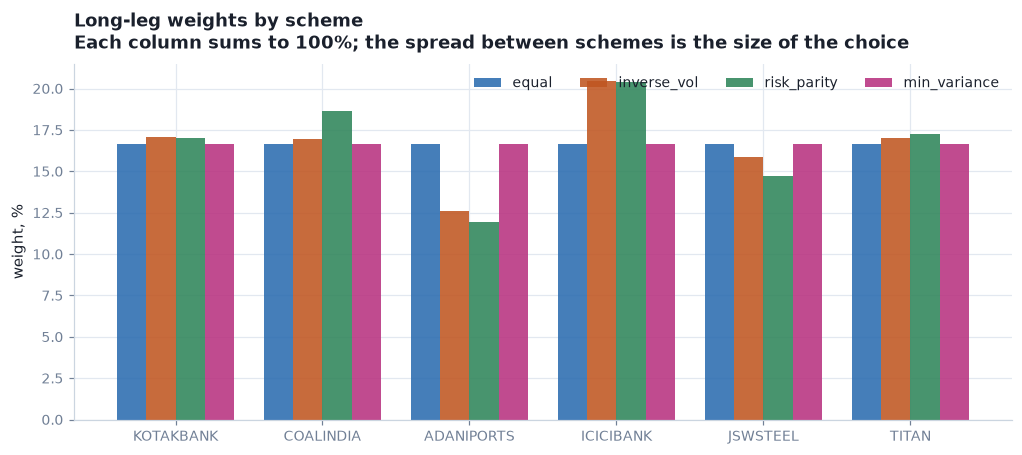

Selected scheme: risk_parity -- equal risk contribution after correlation, which is
the neutral choice when the return forecast is a rank rather than a magnitude.
Notebook 07 found no reliable magnitude to forecast, so a scheme that leans on one
would be fitting noise.


In [4]:
long_rets = rets[long_names].dropna(how="all")
long_cov = rk.shrunk_cov(long_rets)

schemes = pf.compare_schemes(long_rets, long_cov, cap=config.MAX_POSITION_WEIGHT)
display(schemes.round(4))
display(schemes.attrs["stats"].round(2))

fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(schemes.index))
width = 0.2
for i, col in enumerate(schemes.columns):
    ax.bar(x + (i - 1.5) * width, schemes[col].values * 100, width,
           label=col, color=viz.PALETTE[i], alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels([t.replace(".NS", "") for t in schemes.index], fontsize=9)
viz.title(ax, "Long-leg weights by scheme",
          "Each column sums to 100%; the spread between schemes is the size of the choice")
ax.set_ylabel("weight, %"); ax.legend(ncol=4)
viz.save(fig, "10_weighting_schemes"); plt.show()

SCHEME = "risk_parity"
print(f"Selected scheme: {SCHEME} -- equal risk contribution after correlation, which is")
print("the neutral choice when the return forecast is a rank rather than a magnitude.")
print("Notebook 07 found no reliable magnitude to forecast, so a scheme that leans on one")
print("would be fitting noise.")

## 4. Gross exposure from the macro chain

`regime_gross()` reads notebook 02's risk label and notebook 01's macro nowcast out of
`dashboard.json`. This is the link that makes the top-down chain operational rather than
decorative.

In [5]:
gross, why = pf.regime_gross()
print(f"gross exposure : {gross:.2f}x")
print(f"rationale      : {why}")
print(f"table          : {config.GROSS_BY_REGIME}")

chain = dashboard.summary()
display(chain[chain["notebook"].isin(["01_macro", "02_risk", "05_india_market",
                                      "07_signal_validation", "08_earnings_quality"])])

gross exposure : 1.00x
rationale      : notebook 02 risk regime = Neutral; macro nowcast Mixed (no adjustment)
table          : {'Risk-On': 1.5, 'Neutral': 1.0, 'Risk-Off': 0.5}


,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28


## 5. Building the book

Each leg is weighted by the selected scheme, then the two are scaled so their **beta
contributions cancel**. Dollar neutrality and beta neutrality are printed side by side —
the gap between them is exactly the market exposure a dollar-neutral book would have been
carrying without saying so.

In [6]:
long_w = pf.risk_parity(long_cov)
short_cov = rk.shrunk_cov(rets[short_names].dropna(how="all"))
short_w = pf.risk_parity(short_cov)

books = {}
for mode in ("dollar", "beta"):
    books[mode] = pf.build_long_short(long_w, short_w, betas, gross=gross, neutrality=mode)

rows = []
for mode, b in books.items():
    rows.append({"neutrality": b.attrs["method"], "gross": b.attrs["gross"],
                 "net": b.attrs["net"], "net_beta": b.attrs["net_beta"],
                 "long_gross": b.attrs["long_scale"], "short_gross": b.attrs["short_scale"]})
display(pd.DataFrame(rows).set_index("neutrality").round(4))

book = books["beta"]
print(f"\nUsing the {book.attrs['method']} book.")
print(f"The dollar-neutral version carries a net beta of "
      f"{books['dollar'].attrs['net_beta']:+.3f} -- that is market exposure a book "
      f"called 'neutral' would have been running.")

,gross,net,net_beta,long_gross,short_gross
neutrality,,,,,
dollar-neutral,1.00,0.00,0.09,0.50,0.50
beta-neutral,1.00,-0.10,0.00,0.45,0.55



Using the beta-neutral book.
The dollar-neutral version carries a net beta of +0.088 -- that is market exposure a book called 'neutral' would have been running.


### Order of operations, and why it is not arbitrary

Caps are applied at the gross the macro regime authorised, and vol targeting then runs with
`max_leverage=1.0` — it may **de-risk but not lever up**. That asymmetry is deliberate.
Scaling down cannot breach a cap; scaling up multiplies every weight straight back through
both the position cap and the gross budget, so a 12% position cap silently becomes a 21%
position at 1.7x and the book carries leverage the risk regime never approved.

The consequence is that the vol target is a **ceiling, not a promise**. When the book's
ex-ante vol comes in below target, the shortfall is reported rather than levered away.

In [7]:
capped = pf.apply_caps(book["weight"], sectors,
                       max_pos=config.MAX_POSITION_WEIGHT,
                       max_sector=config.MAX_SECTOR_WEIGHT)
book["weight_capped"] = capped

targeted, scale = pf.vol_target(capped, cov, config.TARGET_PORTFOLIO_VOL_PCT,
                                max_leverage=1.0)
book["weight_final"] = targeted
attrs = targeted.attrs

pre_vol, post_vol = attrs["vol_before_%"], attrs["vol_after_%"]
sec_gross = targeted.abs().groupby(pd.Series(sectors)).sum()
print(f"position cap   : max |weight| {targeted.abs().max():.1%} "
      f"(limit {config.MAX_POSITION_WEIGHT:.0%})")
print(f"sector cap     : max sector {sec_gross.max():.1%} "
      f"(limit {config.MAX_SECTOR_WEIGHT:.0%})")
print(f"vol            : {pre_vol:.2f}% -> {post_vol:.2f}% "
      f"(target {config.TARGET_PORTFOLIO_VOL_PCT}%)")
print(f"scale          : {attrs['applied_scale']:.3f}x applied, "
      f"{attrs['required_scale']:.3f}x needed to reach the target")
if attrs["constrained"]:
    print(f"                 -> vol target NOT reached: it would need "
          f"{attrs['required_scale']:.2f}x leverage, above the {gross:.1f}x gross budget")
    print(f"                    the risk regime set. The book runs under target, deliberately.")
print(f"final gross    : {targeted.abs().sum():.3f}x   net {targeted.sum():+.3f}x")

# Assert on the FINAL weights, not the pre-leverage ones. An earlier version of this
# notebook checked `capped` and printed "no breach" for a book whose largest position,
# after a 1.7x vol-target scale, was 23%.
assert targeted.abs().max() <= config.MAX_POSITION_WEIGHT + 1e-9, "position cap breached"
assert sec_gross.max() <= config.MAX_SECTOR_WEIGHT + 1e-9, "sector cap breached"
assert targeted.abs().sum() <= gross + 1e-9, "gross exceeds the regime budget"
print("\ncaps verified on the FINAL weights: no position, sector or gross breach")

display(book[["side", "beta", "weight", "weight_capped", "weight_final"]].round(4))

position cap   : max |weight| 12.0% (limit 12%)
sector cap     : max sector 24.0% (limit 30%)
vol            : 6.72% -> 6.72% (target 12.0%)
scale          : 1.000x applied, 1.787x needed to reach the target
                 -> vol target NOT reached: it would need 1.79x leverage, above the 1.0x gross budget
                    the risk regime set. The book runs under target, deliberately.
final gross    : 1.000x   net -0.082x

caps verified on the FINAL weights: no position, sector or gross breach


,side,beta,weight,weight_capped,weight_final
ticker,,,,,
KOTAKBANK.NS,long,0.99,0.08,0.08,0.08
COALINDIA.NS,long,0.56,0.08,0.09,0.09
ADANIPORTS.NS,long,1.39,0.05,0.05,0.05
ICICIBANK.NS,long,0.92,0.09,0.09,0.09
JSWSTEEL.NS,long,1.14,0.07,0.07,0.07
TITAN.NS,long,0.91,0.08,0.08,0.08
TMPV.NS,short,1.37,-0.07,-0.07,-0.07
DRREDDY.NS,short,0.57,-0.13,-0.12,-0.12
HINDUNILVR.NS,short,0.61,-0.13,-0.12,-0.12


## 6. Lot sizes

Notebook 09 writes the live table. When it has not run — or the NSE derivatives endpoints
were unavailable, which is their normal condition — `portfolio.lot_table()` falls back to
the dated snapshot in `config.LOT_SIZE_FALLBACK`. That fallback is what makes notebook 09
safely cuttable, and the source of every lot size used is printed rather than assumed.

In [8]:
lots_path = config.OUTPUT_DIR / "fno_lots.csv"
live_lots = None
if lots_path.exists():
    live_lots = pd.read_csv(lots_path, index_col=0)["lot"]
    print(f"live lot sizes from notebook 09: {lots_path}")
else:
    print(f"{lots_path} not found -- using the static fallback "
          f"(snapshot {config.LOT_SIZE_FALLBACK_ASOF})")

lt = pf.lot_table(book.index, live=live_lots)
display(lt)
if lt.attrs["n_diverged"]:
    print(f"WARNING: {lt.attrs['n_diverged']} lot size(s) differ between live and "
          f"fallback -- SEBI revises these, and a stale entry sizes a real trade wrongly.")
if lt.attrs["n_missing"]:
    print(f"WARNING: {lt.attrs['n_missing']} name(s) have no lot size at all.")
lots = lt["lot"]
prices = panel.iloc[-1].reindex(book.index)

live lot sizes from notebook 09: G:\stock market analysis\.claude\worktrees\code-review-quotes-3844ce\outputs\fno_lots.csv


,lot_fallback,lot_live,lot,source,diverged
KOTAKBANK.NS,"2,000.00",2000,2000,live,False
COALINDIA.NS,"1,350.00",1350,1350,live,False
ADANIPORTS.NS,475.00,475,475,live,False
ICICIBANK.NS,700.00,700,700,live,False
JSWSTEEL.NS,675.00,675,675,live,False
TITAN.NS,175.00,175,175,live,False
TMPV.NS,"1,600.00",1600,1600,live,False
DRREDDY.NS,625.00,625,625,live,False
HINDUNILVR.NS,300.00,300,300,live,False
TATACONSUM.NS,550.00,550,550,live,False


## 7. Trap #5 — can this book actually be traded?

`assert_implementable` checks every short leg against one whole futures lot at the stated
capital. When a leg fails, it reports the **minimum capital that would work**, because
"raise the book to ₹2.1 crore or drop this name" is actionable and "weights look fine" is
not.

Then quantisation, with the two sides treated differently: longs are cash equity and buy in
single shares, so their rounding is negligible; shorts are futures and round to whole lots,
so theirs is first-order.

Two rules keep the traded book honest:

- **Rounding never goes up through the position cap.** Nearest-lot rounding turned a 12%
  DRREDDY target (1.68 lots) into a 14.3% position; a lot that would breach the cap is
  dropped instead, and the name is reported.
- **The long leg is re-sized to the short leg as traded.** Beta neutrality was solved on
  continuous weights; once the shorts are whole lots the legs no longer cancel. Longs
  trade in single shares, so they absorb the difference — bounded by the position cap and
  the regime's gross budget.

The caps are then asserted on the **realised** weights, and those are what notebooks 11–14
read.

In [9]:
final_book = book[["side", "weight_final"]].rename(columns={"weight_final": "weight"})

try:
    impl = pf.assert_implementable(final_book, prices, lots, capital=CAPITAL,
                                   label="model book")
    print(f"TRAP #5 GUARD PASSED: {impl.attrs['result']} at capital INR {CAPITAL:,.0f}\n")
    display(impl.round(2))
    implementable = True
except AssertionError as exc:
    implementable = False
    print(f"TRAP #5 GUARD FIRED:\n{exc}\n")
    raise

TRAP #5 GUARD PASSED: all 5 short leg(s) expressible in whole lots at capital INR 10,000,000



,target_weight,lot,lot_value,lots_affordable,lot_as_%_of_capital,min_capital,ok
ticker,,,,,,,
TMPV.NS,-0.07,"1,600.00","484,160.01",1.41,4.84,"7,074,517.70",True
DRREDDY.NS,-0.12,625.00,"736,312.48",1.63,7.36,"6,135,937.37",True
HINDUNILVR.NS,-0.12,300.00,"580,890.01",2.07,5.81,"4,840,750.12",True
TATACONSUM.NS,-0.12,550.00,"547,085.01",2.19,5.47,"4,559,041.72",True
WIPRO.NS,-0.11,"3,000.00","501,240.01",2.25,5.01,"4,447,861.34",True


,side,construction_weight,target_weight,lot,unit_value,target_units,units,realised_weight,weight_error_pp,note
ticker,,,,,,,,,,
KOTAKBANK.NS,long,0.08,0.06,1.00,416.55,"1,501.17","1,501.00",0.06,-0.00,
COALINDIA.NS,long,0.09,0.07,1.00,426.95,"1,606.81","1,607.00",0.07,0.00,
ADANIPORTS.NS,long,0.05,0.04,1.00,"1,760.10",249.31,249.00,0.04,-0.01,
ICICIBANK.NS,long,0.09,0.07,1.00,"1,382.90",541.44,541.00,0.07,-0.01,
JSWSTEEL.NS,long,0.07,0.05,1.00,"1,275.80",423.74,424.00,0.05,0.00,
TITAN.NS,long,0.08,0.06,1.00,"4,989.50",127.20,127.00,0.06,-0.01,
TMPV.NS,short,-0.07,-0.07,"1,600.00","484,160.01",-1.41,-1.00,-0.05,2.00,
DRREDDY.NS,short,-0.12,-0.12,625.00,"736,312.48",-1.63,-1.00,-0.07,4.64,rounded down 1 unit(s) to respect the 12% posi...
HINDUNILVR.NS,short,-0.12,-0.12,300.00,"580,890.01",-2.07,-2.00,-0.12,0.38,


long leg re-sized x0.801 (bound: beta match; x0.801 needed for an exact beta match)
net beta     +0.0119 as constructed -> -0.0002 as traded
target gross 0.9085x -> realised 0.8151x
target net   -0.1737x -> realised -0.0807x
tracking error from lot rounding: 5.32 pp
rounded down to respect the position cap: ['DRREDDY.NS']

mean |error|  longs 0.004 pp   shorts 1.865 pp
The short leg's rounding error is 420x the long leg's. That ratio is trap #5 in one number.

caps verified on the REALISED weights: max position 11.62%, max sector 22.56%, gross 0.815x


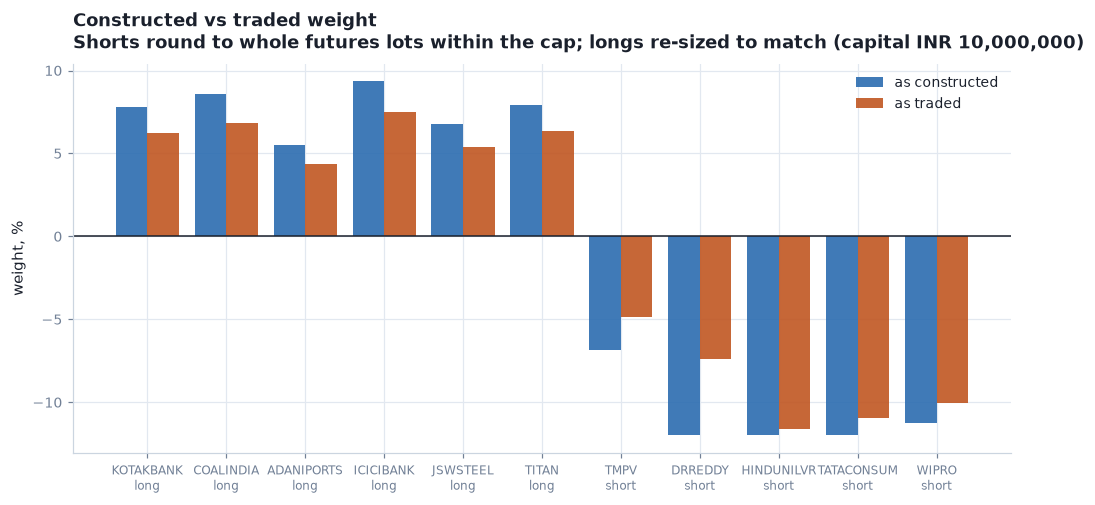

In [10]:
# Shorts round to whole lots -- never up through the position cap -- and the long leg,
# which buys in single shares, is then re-sized to the short leg *as traded*, so the
# book is beta-neutral on the positions that will actually exist.
q = pf.rematch_long_leg(final_book, prices, lots, betas.reindex(final_book.index),
                        capital=CAPITAL, max_pos=config.MAX_POSITION_WEIGHT, gross=gross)
display(q[["side", "construction_weight", "target_weight", "lot", "unit_value",
           "target_units", "units", "realised_weight", "weight_error_pp", "note"]].round(4))

print(f"long leg re-sized x{q.attrs['long_scale']:.3f} "
      f"(bound: {q.attrs['long_scale_bound']}; x{q.attrs['required_long_scale']:.3f} "
      f"needed for an exact beta match)")
print(f"net beta     {q.attrs['construction_net_beta']:+.4f} as constructed -> "
      f"{q.attrs['realised_net_beta']:+.4f} as traded")
print(f"target gross {q.attrs['target_gross']:.4f}x -> realised "
      f"{q.attrs['realised_gross']:.4f}x")
print(f"target net   {q.attrs['target_net']:+.4f}x -> realised "
      f"{q.attrs['realised_net']:+.4f}x")
print(f"tracking error from lot rounding: {q.attrs['tracking_error_pp']:.2f} pp")
if q.attrs["cap_limited"]:
    print(f"rounded down to respect the position cap: {q.attrs['cap_limited']}")
if q.attrs["dropped_to_zero"]:
    print(f"rounded away entirely: {q.attrs['dropped_to_zero']}")

longs_err = q[q["side"] == "long"]["weight_error_pp"].abs()
shorts_err = q[q["side"] == "short"]["weight_error_pp"].abs()
print(f"\nmean |error|  longs {longs_err.mean():.3f} pp   shorts {shorts_err.mean():.3f} pp")
print(f"The short leg's rounding error is {shorts_err.mean() / max(longs_err.mean(), 1e-9):,.0f}x "
      f"the long leg's. That ratio is trap #5 in one number.")

# Caps are enforced on the positions that will be traded, not only on the targets.
# An earlier version checked targets alone and exported a 14.3% short against a 12% cap.
sec_real = q["realised_weight"].abs().groupby(pd.Series(sectors)).sum()
assert q["realised_weight"].abs().max() <= config.MAX_POSITION_WEIGHT + 1e-9, \
    "a realised position breaches the position cap"
assert sec_real.max() <= config.MAX_SECTOR_WEIGHT + 1e-9, "a realised sector breaches the cap"
assert q.attrs["realised_gross"] <= gross + 1e-9, "realised gross exceeds the regime budget"
print(f"\ncaps verified on the REALISED weights: max position "
      f"{q['realised_weight'].abs().max():.2%}, max sector {sec_real.max():.2%}, "
      f"gross {q.attrs['realised_gross']:.3f}x")

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(q))
ax.bar(x - 0.2, q["construction_weight"] * 100, 0.4, label="as constructed",
       color=viz.PALETTE[0], alpha=0.9)
ax.bar(x + 0.2, q["realised_weight"] * 100, 0.4, label="as traded",
       color=viz.PALETTE[1], alpha=0.9)
ax.axhline(0, color=viz.INK, lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"{t.replace('.NS', '')}\n{q.loc[t, 'side']}" for t in q.index],
                   fontsize=8)
viz.title(ax, "Constructed vs traded weight",
          f"Shorts round to whole futures lots within the cap; longs re-sized to match "
          f"(capital INR {CAPITAL:,.0f})")
ax.set_ylabel("weight, %"); ax.legend()
viz.save(fig, "10_target_vs_realised"); plt.show()

In [11]:
cap_grid = [5_000_000, 10_000_000, 25_000_000, 50_000_000, 100_000_000]
rows = []
for c in cap_grid:
    qq = pf.quantize_to_lots(final_book, prices, lots, capital=c)
    try:
        pf.assert_implementable(final_book, prices, lots, capital=c)
        ok = True
    except AssertionError:
        ok = False
    rows.append({"capital_INR": c, "implementable": ok,
                 "tracking_error_pp": qq.attrs["tracking_error_pp"],
                 "realised_gross": qq.attrs["realised_gross"],
                 "names_rounded_to_zero": len(qq.attrs["dropped_to_zero"])})
grid = pd.DataFrame(rows).set_index("capital_INR")
display(grid.round(3))
print("Lot quantisation is a capital-size problem, not a modelling one. The same weights")
print("are untradeable small and near-exact large -- which is why the guard reports a")
print("minimum capital rather than just refusing.")

,implementable,tracking_error_pp,realised_gross,names_rounded_to_zero
capital_INR,,,,
5000000,False,12.45,0.88,1
10000000,True,5.32,0.91,0
25000000,True,1.92,0.98,0
50000000,True,1.17,0.98,0
100000000,True,0.72,0.99,0


Lot quantisation is a capital-size problem, not a modelling one. The same weights
are untradeable small and near-exact large -- which is why the guard reports a
minimum capital rather than just refusing.


## 8. Capacity: can the market absorb it?

Position size against 20-day average daily traded value. A position that is 40% of a day's
volume is not a position, it is a week of slippage.

In [12]:
adv_rows = {}
for t in book.index:
    d = frames.get(t)
    if d is None or "Volume" not in d.columns:
        continue
    adv_rows[t] = float((d["Volume"] * d["Close"]).tail(20).mean())
adv = pd.Series(adv_rows)

# Measured on the traded positions, not the targets.
traded = q[["side", "realised_weight"]].rename(columns={"realised_weight": "weight"})
liq = pf.liquidity_check(traded, adv, capital=CAPITAL,
                         max_pct_adv=config.MAX_PCT_OF_ADV)
display(liq.round(3))
print(f"limit: {liq.attrs['max_pct_adv']:.0f}% of ADV | breaches: {liq.attrs['n_breach']}")
if liq.attrs["n_breach"] == 0:
    print(f"At INR {CAPITAL:,.0f} against Nifty 50 liquidity, capacity is not the binding "
          f"constraint -- lot size is.")

,side,position_value,adv_value,pct_of_adv,days_to_trade,breach
ticker,,,,,,
KOTAKBANK.NS,long,"625,241.53","4,954,291,135.32",0.01,0.00,False
COALINDIA.NS,long,"686,108.67","4,544,542,043.99",0.01,0.00,False
ADANIPORTS.NS,long,"438,264.89","4,168,446,359.72",0.01,0.00,False
ICICIBANK.NS,long,"748,148.91","12,430,398,379.50",0.01,0.00,False
JSWSTEEL.NS,long,"540,939.22","2,136,716,930.85",0.03,0.00,False
TITAN.NS,long,"633,666.50","2,522,987,323.36",0.03,0.00,False
TMPV.NS,short,"484,160.01","2,359,743,608.07",0.02,0.00,False
DRREDDY.NS,short,"736,312.48","1,313,534,377.90",0.06,0.01,False
HINDUNILVR.NS,short,"1,161,780.03","2,422,598,260.08",0.05,0.01,False


limit: 10% of ADV | breaches: 0
At INR 10,000,000 against Nifty 50 liquidity, capacity is not the binding constraint -- lot size is.


## 9. Export and hand off

In [13]:
export = q.join(book[["beta"]]).join(pd.Series(sectors, name="sector"))
export["position_value_INR"] = export["realised_weight"] * CAPITAL
export["pct_of_adv"] = liq["pct_of_adv"]
export.index.name = "ticker"
out_path = config.OUTPUT_DIR / "portfolio_book.csv"
export.round(6).to_csv(out_path)
print(f"Wrote {out_path}  ({export.shape[0]} positions)")

realised = export["realised_weight"]
payload = {
    "signal": (f"{int((export['side'] == 'long').sum())}L / "
               f"{int((export['side'] == 'short').sum())}S, "
               f"gross {q.attrs['realised_gross']:.2f}x, net "
               f"{q.attrs['realised_net']:+.2f}x"),
    "score": round(float(pf.portfolio_vol(realised, cov)), 2),
    "as_of": str(panel.index.max().date()),
    "capital_INR": CAPITAL,
    "scheme": SCHEME,
    "neutrality": book.attrs["method"],
    "gross_regime": {"gross": gross, "rationale": why},
    "target": {"gross": round(q.attrs["target_gross"], 4),
               "net": round(q.attrs["target_net"], 4),
               "vol_%": round(post_vol, 2),
               "vol_target_%": config.TARGET_PORTFOLIO_VOL_PCT},
    "realised": {"gross": round(q.attrs["realised_gross"], 4),
                 "net": round(q.attrs["realised_net"], 4),
                 "vol_%": round(pf.portfolio_vol(realised, cov), 2)},
    "tracking_error_pp": round(q.attrs["tracking_error_pp"], 3),
    "lot_source": str(lt["source"].iloc[0]),
    "positions": {t: {"side": r["side"],
                      "target_weight": round(float(r["target_weight"]), 4),
                      "realised_weight": round(float(r["realised_weight"]), 4),
                      "units": (None if not np.isfinite(r["units"]) else int(r["units"])),
                      "sector": sectors.get(t, "")}
                  for t, r in export.iterrows()},
    "caps": {"max_position": config.MAX_POSITION_WEIGHT,
             "max_sector": config.MAX_SECTOR_WEIGHT,
             "max_position_used": round(float(realised.abs().max()), 4)},
    "liquidity_breaches": int(liq.attrs["n_breach"]),
    "min_capital_for_shorts": (None if impl.empty
                               else round(float(impl["min_capital"].max()), 0)),
    "exports": ["outputs/portfolio_book.csv"],
}
dashboard.append("10_portfolio", payload)
display(dashboard.summary())

Wrote G:\stock market analysis\.claude\worktrees\code-review-quotes-3844ce\outputs\portfolio_book.csv  (11 positions)


,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.82x, net -0.08x",5.54,2026-09-11,2026-09-11 07:18:23


In [14]:
print("=" * 92)
print("THE BOOK")
print("=" * 92)
for side in ("long", "short"):
    sub = export[export["side"] == side]
    print(f"\n{side.upper()}  ({len(sub)} names, gross "
          f"{sub['realised_weight'].abs().sum():.3f}x)")
    for t, r in sub.iterrows():
        unit = "shares" if side == "long" else f"lots x{int(r['lot'])}"
        print(f"   {t.replace('.NS', ''):14s} {r['sector']:24s} "
              f"target {r['target_weight']:+7.2%}  realised {r['realised_weight']:+7.2%}  "
              f"{abs(int(r['units'])):>6,} {unit:14s} INR {abs(r['position_value_INR']):>12,.0f}")
print(f"\ngross {q.attrs['realised_gross']:.3f}x   net {q.attrs['realised_net']:+.3f}x   "
      f"ex-ante vol {pf.portfolio_vol(realised, cov):.2f}%")
print("=" * 92)

THE BOOK

LONG  (6 names, gross 0.367x)
   KOTAKBANK      Financial Services       target  +6.25%  realised  +6.25%   1,501 shares         INR      625,242
   COALINDIA      Oil Gas & Fuels          target  +6.86%  realised  +6.86%   1,607 shares         INR      686,109
   ADANIPORTS     Services                 target  +4.39%  realised  +4.38%     249 shares         INR      438,265
   ICICIBANK      Financial Services       target  +7.49%  realised  +7.48%     541 shares         INR      748,149
   JSWSTEEL       Metals & Mining          target  +5.41%  realised  +5.41%     424 shares         INR      540,939
   TITAN          Consumer Durables        target  +6.35%  realised  +6.34%     127 shares         INR      633,666

SHORT  (5 names, gross 0.448x)
   TMPV           Automobile               target  -6.84%  realised  -4.84%       1 lots x1600     INR      484,160
   DRREDDY        Healthcare               target -12.00%  realised  -7.36%       1 lots x625      INR      736,312


## What this hands to notebook 11

`outputs/portfolio_book.csv` — a sized, beta-matched, capped, lot-quantised long/short
book, plus the realised weights that differ from the targets.

Notebook 11 runs the risk engine on **realised** weights, not target weights. That
distinction matters: the 4-point-something percentage of tracking error introduced above
is real risk that a target-weight risk report would not see. It also runs the same
functions against `data/portfolio.csv` if that file exists, so the model book and a real
book are one code path with two inputs.